In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
from scipy.stats import multivariate_normal

In [2]:
import sklearn

In [13]:
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)

In [192]:
sigma = 0.02
N_points = 1000

In [193]:
Mirr = []
chi = []
for i in range(10):
    chii = scipy.stats.uniform.rvs(0, 1, N_points)
    chi = np.append(chi,chii)
    M = norm.rvs(1,sigma,N_points)
    Mirri = M*f(chii)
    Mirr = np.append(Mirr, Mirri)

(array([0.06692947, 0.32393865, 0.78173624, 1.28772306, 1.84725345,
        2.77623453, 4.42805392, 7.96728444, 6.52696219, 0.76567317]),
 array([0.68828633, 0.72563908, 0.76299184, 0.80034459, 0.83769734,
        0.87505009, 0.91240284, 0.9497556 , 0.98710835, 1.0244611 ,
        1.06181385]),
 <BarContainer object of 10 artists>)

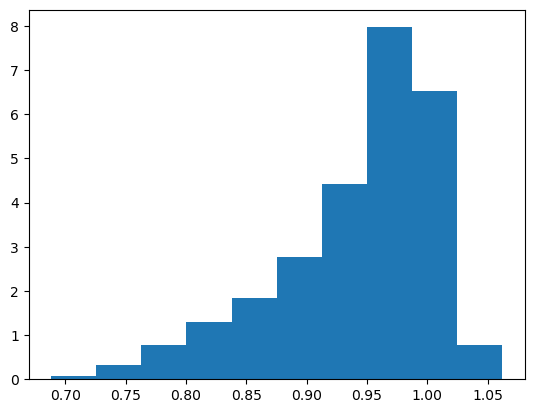

In [194]:
plt.hist(Mirr,density=True)

[]

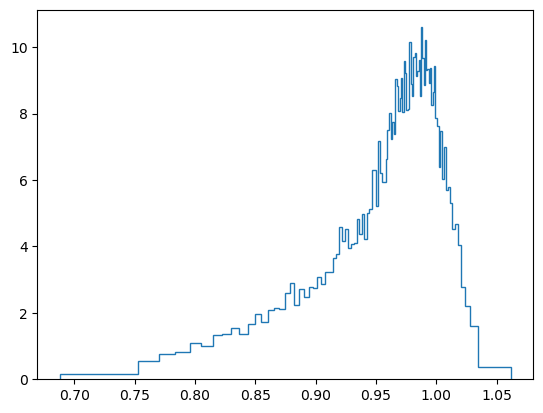

In [195]:
bins100 = np.append(np.sort(Mirr)[::100], np.max(Mirr)) 
#bins30 = np.append(np.sort(Mirr)[::30], np.max(Mirr))
plt.hist(Mirr, bins=bins100, density=True, histtype="step") 
#plt.hist(Mirr, bins=bins30, density=True, histtype="step")
plt.plot()

(array([0.02648873, 0.02648873, 0.02648873, 0.13244364, 0.11919928,
        0.11919928, 0.30462038, 0.31786475, 0.51653021, 0.43706403,
        0.68870695, 0.66221822, 0.90061678, 0.88737242, 0.8211506 ,
        1.2317259 , 1.01981607, 1.39065827, 1.417147  , 1.35092518,
        1.6423012 , 1.76150048, 1.85421103, 2.06612086, 2.27803069,
        2.6091398 , 2.54291798, 2.70185035, 2.90051582, 3.21838057,
        4.01304244, 4.251441  , 4.23819663, 4.74148248, 5.90698656,
        6.22485131, 7.88039687, 8.78101365, 8.95319039, 9.40349878,
        9.12536713, 7.56253212, 5.86725347, 4.4368621 , 2.37074124,
        1.58932374, 0.7814175 , 0.2251542 , 0.09271055, 0.02648873]),
 array([0.68828633, 0.69583671, 0.70338709, 0.71093747, 0.71848786,
        0.72603824, 0.73358862, 0.741139  , 0.74868938, 0.75623976,
        0.76379014, 0.77134052, 0.7788909 , 0.78644129, 0.79399167,
        0.80154205, 0.80909243, 0.81664281, 0.82419319, 0.83174357,
        0.83929395, 0.84684434, 0.85439472, 0.

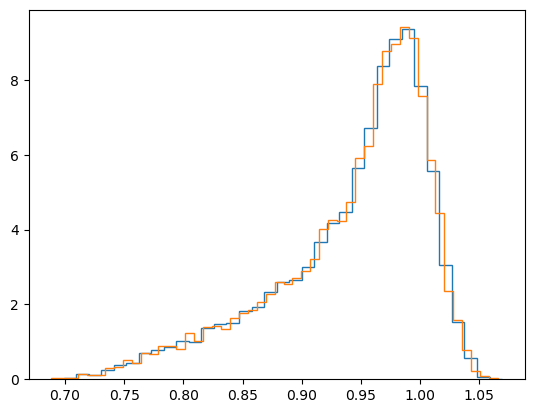

In [196]:
import astropy.visualization.hist
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True)
astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True)

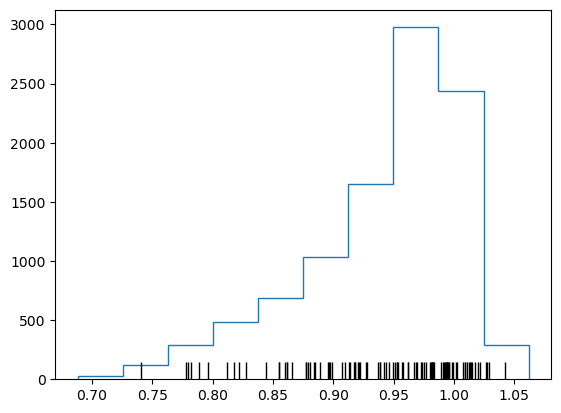

In [197]:
plt.hist(Mirr,histtype="step")
plt.plot(Mirr[:100], 0*Mirr[:100], '|', color='k', markersize=25);

In [198]:
from sklearn.neighbors import KernelDensity

In [199]:
xgrid = np.linspace(Mirr.min(),Mirr.max(),10000)

In [200]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

[]

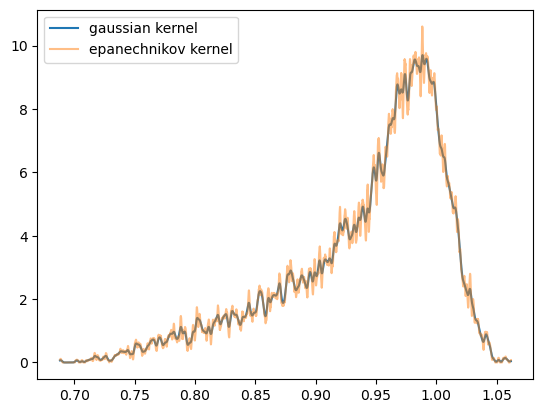

In [201]:
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 0.5)
plt.legend()
plt.plot()

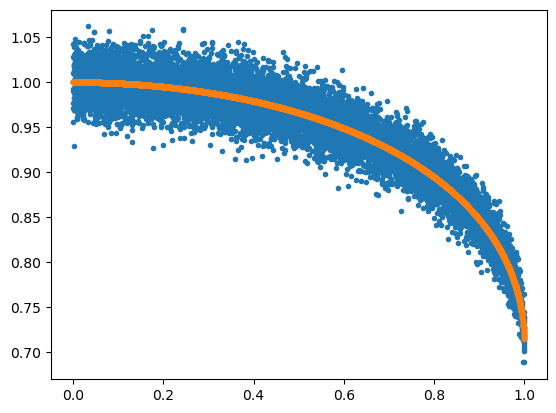

In [202]:
plt.scatter(chi,Mirr,marker='.')
plt.scatter(chi,f(chi),marker='.')

In [203]:
print(stats.ks_2samp(Mirr,f(chi)))

KstestResult(statistic=0.1548, pvalue=6.553311112773081e-105, statistic_location=0.9999999991173996, statistic_sign=-1)


In [208]:
N_sigma = 30
sigmas= np.logspace(-5,1,N_sigma)
sigmas

array([1.00000000e-05, 1.61026203e-05, 2.59294380e-05, 4.17531894e-05,
       6.72335754e-05, 1.08263673e-04, 1.74332882e-04, 2.80721620e-04,
       4.52035366e-04, 7.27895384e-04, 1.17210230e-03, 1.88739182e-03,
       3.03919538e-03, 4.89390092e-03, 7.88046282e-03, 1.26896100e-02,
       2.04335972e-02, 3.29034456e-02, 5.29831691e-02, 8.53167852e-02,
       1.37382380e-01, 2.21221629e-01, 3.56224789e-01, 5.73615251e-01,
       9.23670857e-01, 1.48735211e+00, 2.39502662e+00, 3.85662042e+00,
       6.21016942e+00, 1.00000000e+01])

/tmp/ipykernel_63018/1857989315.py:10: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])


Text(0.5, 0, '$M_{irr}$')

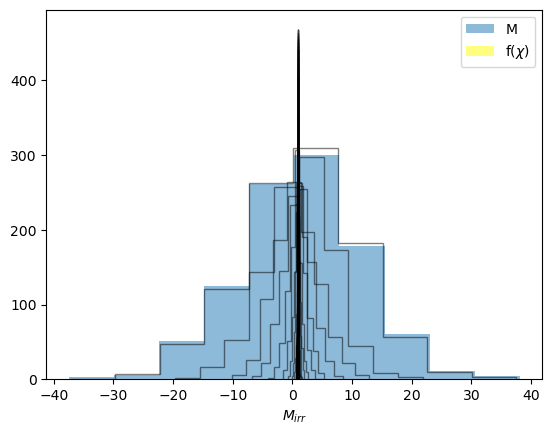

In [212]:
KSs_f = []
KSs_M = []

for i in range(N_sigma):
    chi = scipy.stats.uniform.rvs(0, 1, N_points)
    M = norm.rvs(1,sigmas[i],N_points)
    Mirri = M*f(chi)
    plt.hist(Mirri,histtype="step",color='k',alpha=0.5)
    
    KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])
    KSs_M = np.append(KSs_M, stats.ks_2samp(Mirri,M)[1])

plt.hist(M,alpha=0.5,label='M')
plt.hist(f(chi),alpha=0.5,color='yellow',label=r'f($\chi$)')
plt.legend()
plt.xlabel(r'$M_{irr}$')

Text(0, 0.5, 'KS M-f')

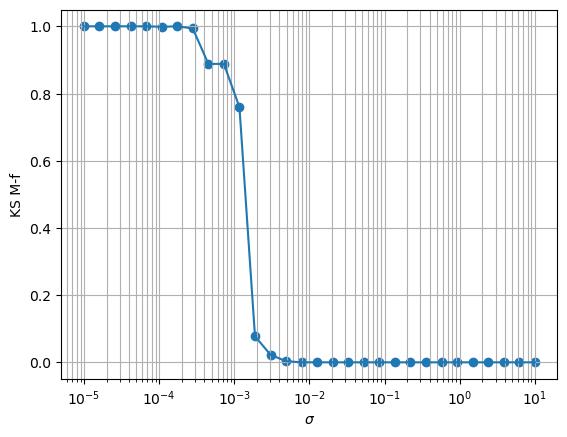

In [213]:
plt.grid(which='both')
plt.plot(sigmas, KSs_f)
plt.scatter(sigmas, KSs_f)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS M-f')


Text(0, 0.5, 'KS M-f')

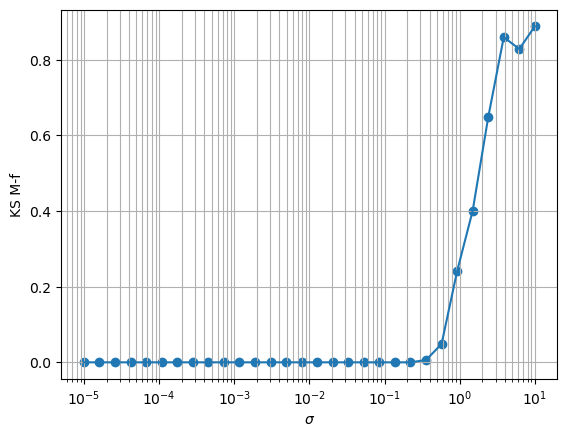

In [216]:
plt.grid(which='both')
plt.plot(sigmas, KSs_M)
plt.scatter(sigmas, KSs_M)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS M-f')